LLM-Powered FAQ Chatbot

**Objective:** Build an intelligent FAQ chatbot using Hugging Face Transformers (BERT/DistilBERT) that can answer questions based on a custom knowledge base.

**Techniques Used:**
- Sentence Transformers for semantic similarity
- Cosine Similarity for question matching
- Hugging Face Transformers pipeline
- Retrieval-Augmented Generation (RAG) concept
- Conversation history tracking




Install & Import Libraries

In [19]:
# Install required libraries
# Run this cell first if libraries are not installed
# !pip install transformers sentence-transformers torch pandas numpy

In [20]:
import sys
!{sys.executable} -m pip install transformers sentence-transformers torch

In [21]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# Hugging Face
from transformers import pipeline
from sentence_transformers import SentenceTransformer

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

Build Knowledge Base (FAQ Dataset)

In [22]:
# -----------------------------------------------
# Custom FAQ Knowledge Base
# This simulates a real company's support data
# -----------------------------------------------

faq_data = [
    # Account & Login
    {"question": "How do I reset my password?",
     "answer": "To reset your password, go to the login page and click 'Forgot Password'. Enter your email address and we'll send you a reset link within 2 minutes.",
     "category": "Account"},

    {"question": "How can I create a new account?",
     "answer": "You can create a new account by clicking 'Sign Up' on our homepage. Fill in your name, email, and password. You'll receive a verification email to activate your account.",
     "category": "Account"},

    {"question": "Can I change my username?",
     "answer": "Yes, you can change your username in Account Settings > Profile > Edit Username. Note that username changes are limited to once every 30 days.",
     "category": "Account"},

    {"question": "How do I delete my account?",
     "answer": "To delete your account, go to Settings > Account > Delete Account. This action is permanent and all your data will be removed within 30 days.",
     "category": "Account"},

    # Billing & Payments
    {"question": "What payment methods do you accept?",
     "answer": "We accept Visa, MasterCard, American Express, PayPal, and bank transfers. All payments are processed securely through our encrypted payment gateway.",
     "category": "Billing"},

    {"question": "How do I get a refund?",
     "answer": "Refunds are available within 14 days of purchase. Contact our support team at support@company.com with your order ID. Refunds are processed within 5-7 business days.",
     "category": "Billing"},

    {"question": "How can I upgrade my plan?",
     "answer": "You can upgrade your plan anytime in Settings > Subscription > Upgrade. The new plan takes effect immediately and you'll be charged the prorated difference.",
     "category": "Billing"},

    {"question": "Is there a free trial available?",
     "answer": "Yes! We offer a 14-day free trial with full access to all features. No credit card required. You can upgrade to a paid plan anytime during or after the trial.",
     "category": "Billing"},

    # Technical Support
    {"question": "The app is not loading, what should I do?",
     "answer": "Try these steps: 1) Clear your browser cache, 2) Disable browser extensions, 3) Try a different browser, 4) Check your internet connection. If the issue persists, contact support.",
     "category": "Technical"},

    {"question": "How do I report a bug?",
     "answer": "You can report bugs through our Help Center > Report a Bug, or email bugs@company.com. Please include screenshots and steps to reproduce the issue.",
     "category": "Technical"},

    {"question": "What browsers are supported?",
     "answer": "We support Chrome (v90+), Firefox (v88+), Safari (v14+), and Edge (v90+). For the best experience, we recommend using Google Chrome.",
     "category": "Technical"},

    {"question": "Is there a mobile app?",
     "answer": "Yes! Our mobile app is available on iOS (App Store) and Android (Google Play). It includes all core features with a mobile-optimized interface.",
     "category": "Technical"},

    # Features
    {"question": "How do I export my data?",
     "answer": "You can export your data in CSV, Excel, or PDF format from Settings > Data > Export. Large exports may take a few minutes to process.",
     "category": "Features"},

    {"question": "Can I collaborate with my team?",
     "answer": "Absolutely! Team collaboration is available on our Pro and Enterprise plans. You can invite teammates, assign roles, and work on shared projects in real-time.",
     "category": "Features"},

    {"question": "Is there an API available?",
     "answer": "Yes, we provide a REST API with full documentation at docs.company.com/api. API access is available on Pro and Enterprise plans. Rate limits apply.",
     "category": "Features"},

    # Security
    {"question": "How secure is my data?",
     "answer": "Your data is encrypted using AES-256 encryption at rest and TLS 1.3 in transit. We are SOC 2 Type II compliant and conduct regular security audits.",
     "category": "Security"},

    {"question": "Do you offer two-factor authentication?",
     "answer": "Yes! Two-factor authentication (2FA) is available and highly recommended. Enable it in Settings > Security > Two-Factor Authentication using an authenticator app.",
     "category": "Security"},

    # General
    {"question": "How do I contact customer support?",
     "answer": "You can reach our support team via: Email: support@company.com, Live Chat (available 9am-6pm EST), or Phone: 1-800-COMPANY. Average response time is 2 hours.",
     "category": "General"},

    {"question": "What are your business hours?",
     "answer": "Our support team is available Monday-Friday, 9am-6pm EST. For urgent issues outside business hours, use our emergency support at urgent@company.com.",
     "category": "General"},

    {"question": "Where are your servers located?",
     "answer": "Our servers are located in AWS data centers in the US (Virginia), EU (Ireland), and Asia Pacific (Singapore). Data residency options are available for Enterprise plans.",
     "category": "General"}
]

# Convert to DataFrame
df_faq = pd.DataFrame(faq_data)

print(f'Knowledge base created with {len(df_faq)} FAQs')
print(f'\nCategories: {df_faq["category"].unique()}')
print(f'\nDistribution:')
print(df_faq['category'].value_counts())
df_faq.head()

Knowledge base created with 20 FAQs

Categories: ['Account' 'Billing' 'Technical' 'Features' 'Security' 'General']

Distribution:
category
Account      4
Billing      4
Technical    4
Features     3
General      3
Security     2
Name: count, dtype: int64


,question,answer,category
0,How do I reset my password?,"To reset your password, go to the login page a...",Account
1,How can I create a new account?,You can create a new account by clicking 'Sign...,Account
2,Can I change my username?,"Yes, you can change your username in Account S...",Account
3,How do I delete my account?,"To delete your account, go to Settings > Accou...",Account
4,What payment methods do you accept?,"We accept Visa, MasterCard, American Express, ...",Billing


EDA - Knowledge Base Analysis

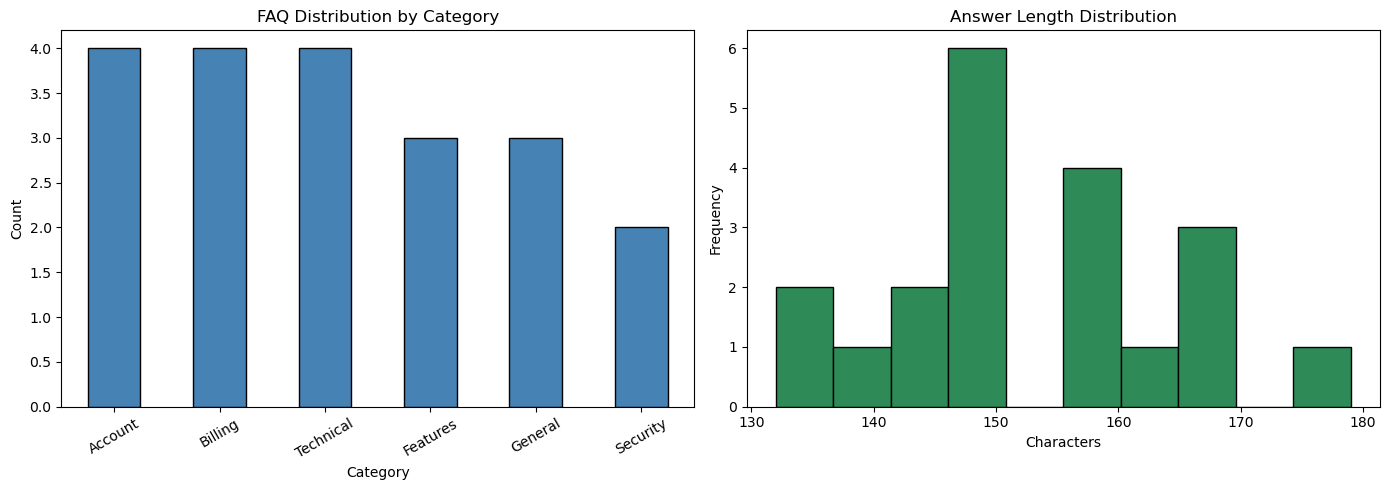

Average answer length: 152 characters


In [23]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category distribution
df_faq['category'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('FAQ Distribution by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Answer length distribution
df_faq['answer_length'] = df_faq['answer'].apply(len)
axes[1].hist(df_faq['answer_length'], bins=10, color='seagreen', edgecolor='black')
axes[1].set_title('Answer Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('images/faq_analysis.png', dpi=150)
plt.show()
print(f'Average answer length: {df_faq["answer_length"].mean():.0f} characters')

Load Sentence Transformer Model (LLM-based Embeddings)

In [24]:

# Load pre-trained Sentence Transformer
# This model converts text into semantic vectors
# Based on BERT architecture


print('Loading Sentence Transformer model...')
print('Model: all-MiniLM-L6-v2 (fast + accurate)')
print('This model is based on BERT and fine-tuned for semantic similarity')

# Load model (downloads automatically on first run ~80MB)
model = SentenceTransformer('all-MiniLM-L6-v2')

print('\nModel loaded successfully')
print(f'Embedding dimension: {model.get_sentence_embedding_dimension()}')

Loading Sentence Transformer model...
Model: all-MiniLM-L6-v2 (fast + accurate)
This model is based on BERT and fine-tuned for semantic similarity


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded successfully
Embedding dimension: 384


Create Embeddings for Knowledge Base

In [25]:

# Convert all FAQ questions to embeddings
# This is the core of semantic search


print('Creating embeddings for knowledge base...')

# Encode all questions
question_embeddings = model.encode(
    df_faq['question'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f'\n Embeddings created!')
print(f'Shape: {question_embeddings.shape}')
print(f'Each question → {question_embeddings.shape[1]}-dimensional vector')

# Save embeddings for later use
os.makedirs('models', exist_ok=True)
np.save('models/question_embeddings.npy', question_embeddings)
print('\n Embeddings saved to models/question_embeddings.npy')

Creating embeddings for knowledge base...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


 Embeddings created!
Shape: (20, 384)
Each question → 384-dimensional vector

 Embeddings saved to models/question_embeddings.npy


Semantic Search Engine

In [26]:
def find_best_answer(user_question, top_k=3, threshold=0.3):
    """
    Find the best matching FAQ answer for a user question.
    
    Args:
        user_question (str): The user's question
        top_k (int): Number of top matches to return
        threshold (float): Minimum similarity score (0-1)
    
    Returns:
        dict: Best match with answer and confidence score
    """
    # Encode user question
    user_embedding = model.encode([user_question])
    
    # Calculate cosine similarity with all FAQ questions
    similarities = cosine_similarity(user_embedding, question_embeddings)[0]
    
    # Get top-k matches
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    
    best_idx = top_indices[0]
    best_score = top_scores[0]
    
    if best_score < threshold:
        return {
            'answer': "I'm sorry, I couldn't find a relevant answer to your question. Please contact our support team at support@company.com for assistance.",
            'matched_question': None,
            'confidence': best_score,
            'category': 'Unknown',
            'found': False
        }
    
    return {
        'answer': df_faq.iloc[best_idx]['answer'],
        'matched_question': df_faq.iloc[best_idx]['question'],
        'confidence': float(best_score),
        'category': df_faq.iloc[best_idx]['category'],
        'found': True,
        'top_matches': [
            {
                'question': df_faq.iloc[top_indices[i]]['question'],
                'score': float(top_scores[i])
            }
            for i in range(min(top_k, len(top_indices)))
        ]
    }

# Test the search engine
test_q = "How can I reset my forgotten password?"
result = find_best_answer(test_q)

print(f'User Question: {test_q}')
print(f'Matched FAQ:   {result["matched_question"]}')
print(f'Confidence:    {result["confidence"]:.2%}')
print(f'Category:      {result["category"]}')
print(f'\nAnswer: {result["answer"]}')

User Question: How can I reset my forgotten password?
Matched FAQ:   How do I reset my password?
Confidence:    90.80%
Category:      Account

Answer: To reset your password, go to the login page and click 'Forgot Password'. Enter your email address and we'll send you a reset link within 2 minutes.


Full Chatbot with Conversation History

In [27]:
class FAQChatbot:
    """
    LLM-powered FAQ Chatbot with:
    - Semantic search using BERT embeddings
    - Conversation history tracking
    - Confidence scoring
    - Fallback handling
    """

    def __init__(self, model, embeddings, faq_df, threshold=0.3):
        self.model = model
        self.embeddings = embeddings
        self.faq_df = faq_df
        self.threshold = threshold
        self.conversation_history = []
        self.session_id = 0

        # Greeting and farewell patterns
        self.greetings = ['hello', 'hi', 'hey', 'good morning', 'good afternoon', 'howdy']
        self.farewells = ['bye', 'goodbye', 'see you', 'thanks', 'thank you', 'that\'s all']

    def _is_greeting(self, text):
        return any(g in text.lower() for g in self.greetings)

    def _is_farewell(self, text):
        return any(f in text.lower() for f in self.farewells)

    def _get_greeting_response(self):
        return "Hello! Welcome to our support chatbot. I can help you with account issues, billing, technical support, and more. What can I help you with today?"

    def _get_farewell_response(self):
        return "Thank you for using our support chatbot!  Have a great day! If you need further assistance, feel free to contact us at support@company.com."

    def chat(self, user_message):
        """
        Process user message and return chatbot response.
        """
        # Add to history
        self.conversation_history.append({
            'role': 'user',
            'message': user_message,
            'turn': len(self.conversation_history) + 1
        })

        # Check for greeting
        if self._is_greeting(user_message) and len(self.conversation_history) <= 2:
            response = self._get_greeting_response()
            confidence = 1.0
            category = 'Greeting'

        # Check for farewell
        elif self._is_farewell(user_message):
            response = self._get_farewell_response()
            confidence = 1.0
            category = 'Farewell'

        else:
            # Semantic search
            result = find_best_answer(user_message, threshold=self.threshold)
            response = result['answer']
            confidence = result['confidence']
            category = result['category']

        # Add bot response to history
        self.conversation_history.append({
            'role': 'bot',
            'message': response,
            'confidence': confidence,
            'category': category,
            'turn': len(self.conversation_history) + 1
        })

        return {
            'response': response,
            'confidence': confidence,
            'category': category
        }

    def get_conversation_summary(self):
        """Return a summary of the conversation."""
        turns = len([m for m in self.conversation_history if m['role'] == 'user'])
        categories = [m.get('category', '') for m in self.conversation_history if m['role'] == 'bot']
        avg_conf = np.mean([m.get('confidence', 0) for m in self.conversation_history if m['role'] == 'bot'])
        return {
            'total_turns': turns,
            'categories_covered': list(set(categories)),
            'avg_confidence': avg_conf
        }

    def reset(self):
        """Reset conversation history."""
        self.conversation_history = []
        print('🔄 Conversation reset.')


# Initialize chatbot
chatbot = FAQChatbot(
    model=model,
    embeddings=question_embeddings,
    faq_df=df_faq,
    threshold=0.3
)

print('Chatbot initialized and ready!')

Chatbot initialized and ready!


 Test the Chatbot - Full Conversation

In [28]:
# Full conversation demo
test_conversations = [
    "Hi there!",
    "I forgot my password and can't login",
    "What payment methods do you support?",
    "I want to get my money back",
    "Is there a mobile application?",
    "How safe is my personal data?",
    "I want to work with my colleagues on a project",
    "The website is not working properly",
    "Thank you, goodbye!"
]

print('=' * 65)
print('            CHATBOT DEMO - FULL CONVERSATION')
print('=' * 65)

chatbot.reset()

for user_msg in test_conversations:
    print(f'\n User: {user_msg}')
    result = chatbot.chat(user_msg)
    print(f' Bot:  {result["response"]}')
    print(f'    Confidence: {result["confidence"]:.2%} | Category: {result["category"]}')
    print('-' * 65)

# Summary
summary = chatbot.get_conversation_summary()
print(f'\n CONVERSATION SUMMARY')
print(f'Total turns: {summary["total_turns"]}')
print(f'Categories: {summary["categories_covered"]}')
print(f'Avg confidence: {summary["avg_confidence"]:.2%}')

            CHATBOT DEMO - FULL CONVERSATION
🔄 Conversation reset.

 User: Hi there!
 Bot:  Hello! Welcome to our support chatbot. I can help you with account issues, billing, technical support, and more. What can I help you with today?
    Confidence: 100.00% | Category: Greeting
-----------------------------------------------------------------

 User: I forgot my password and can't login
 Bot:  To reset your password, go to the login page and click 'Forgot Password'. Enter your email address and we'll send you a reset link within 2 minutes.
    Confidence: 80.40% | Category: Account
-----------------------------------------------------------------

 User: What payment methods do you support?
 Bot:  We accept Visa, MasterCard, American Express, PayPal, and bank transfers. All payments are processed securely through our encrypted payment gateway.
    Confidence: 93.05% | Category: Billing
-----------------------------------------------------------------

 User: I want to get my money b

Chatbot Performance Analysis

In [29]:
# Test with diverse questions and measure performance
evaluation_questions = [
    {"question": "forgot my password", "expected_category": "Account"},
    {"question": "how to pay?", "expected_category": "Billing"},
    {"question": "app crash on my phone", "expected_category": "Technical"},
    {"question": "need refund please", "expected_category": "Billing"},
    {"question": "delete my profile", "expected_category": "Account"},
    {"question": "is there free plan?", "expected_category": "Billing"},
    {"question": "export data to excel", "expected_category": "Features"},
    {"question": "team collaboration features", "expected_category": "Features"},
    {"question": "how to enable 2FA", "expected_category": "Security"},
    {"question": "contact support email", "expected_category": "General"},
]

correct = 0
results_list = []

for item in evaluation_questions:
    result = find_best_answer(item['question'])
    predicted = result['category']
    expected = item['expected_category']
    is_correct = predicted == expected
    if is_correct:
        correct += 1
    results_list.append({
        'question': item['question'],
        'expected': expected,
        'predicted': predicted,
        'confidence': result['confidence'],
        'correct': is_correct
    })

results_df = pd.DataFrame(results_list)
accuracy = correct / len(evaluation_questions)

print(f'Evaluation Results:')
print(results_df[['question', 'expected', 'predicted', 'confidence', 'correct']].to_string(index=False))
print(f'\n Category Accuracy: {accuracy:.2%} ({correct}/{len(evaluation_questions)})')
print(f'Average Confidence: {results_df["confidence"].mean():.2%}')

Evaluation Results:
                   question  expected predicted  confidence  correct
         forgot my password   Account   Account    0.812595     True
                how to pay?   Billing   Billing    0.493270     True
      app crash on my phone Technical Technical    0.602679     True
         need refund please   Billing   Billing    0.809588     True
          delete my profile   Account   Account    0.719355     True
        is there free plan?   Billing   Billing    0.544601     True
       export data to excel  Features  Features    0.715891     True
team collaboration features  Features  Features    0.665247     True
          how to enable 2FA  Security  Security    0.569228     True
      contact support email   General   General    0.718560     True

 Category Accuracy: 100.00% (10/10)
Average Confidence: 66.51%


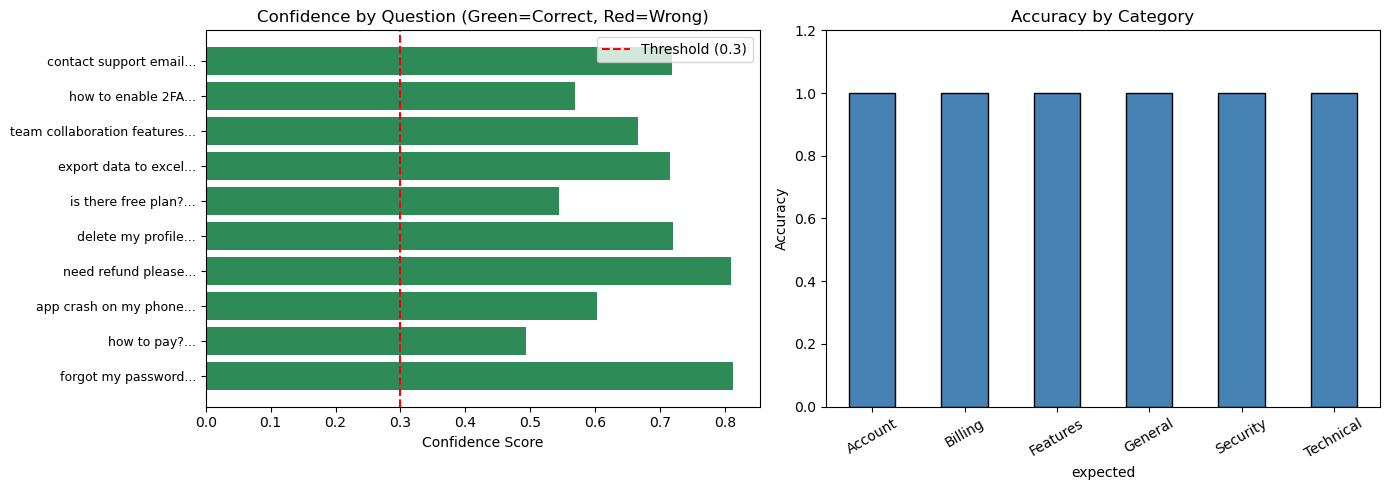

In [30]:
# Visualize confidence scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence by question
colors = ['seagreen' if c else 'salmon' for c in results_df['correct']]
axes[0].barh(range(len(results_df)), results_df['confidence'], color=colors)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels([q[:30]+'...' for q in results_df['question']], fontsize=9)
axes[0].set_xlabel('Confidence Score')
axes[0].set_title('Confidence by Question (Green=Correct, Red=Wrong)')
axes[0].axvline(x=0.3, color='red', linestyle='--', label='Threshold (0.3)')
axes[0].legend()

# Category accuracy
cat_acc = results_df.groupby('expected')['correct'].mean()
cat_acc.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Accuracy by Category')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.2)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('images/performance_analysis.png', dpi=150)
plt.show()

 Save Chatbot Components

In [31]:
import joblib

# Save FAQ data
df_faq.to_csv('models/faq_knowledge_base.csv', index=False)
print(' Knowledge base saved: models/faq_knowledge_base.csv')

# Save embeddings
np.save('models/question_embeddings.npy', question_embeddings)
print(' Embeddings saved: models/question_embeddings.npy')

# Save chatbot config
config = {
    'model_name': 'all-MiniLM-L6-v2',
    'embedding_dim': 384,
    'threshold': 0.3,
    'num_faqs': len(df_faq),
    'categories': df_faq['category'].unique().tolist()
}
with open('models/chatbot_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(' Config saved: models/chatbot_config.json')
print('\n All chatbot components saved successfully!')

 Knowledge base saved: models/faq_knowledge_base.csv
 Embeddings saved: models/question_embeddings.npy
 Config saved: models/chatbot_config.json

 All chatbot components saved successfully!


Interactive Chat Function (Deployment Ready)

In [32]:
def load_and_chat(user_question):
    """
    Load saved chatbot and answer a question.
    This is the deployment-ready function.
    """
    # Load components
    saved_model = SentenceTransformer('all-MiniLM-L6-v2')
    saved_embeddings = np.load('models/question_embeddings.npy')
    saved_faq = pd.read_csv('models/faq_knowledge_base.csv')

    with open('models/chatbot_config.json') as f:
        config = json.load(f)

    # Encode and search
    user_emb = saved_model.encode([user_question])
    sims = cosine_similarity(user_emb, saved_embeddings)[0]
    best_idx = np.argmax(sims)
    best_score = sims[best_idx]

    if best_score < config['threshold']:
        return "Sorry, I couldn't find an answer. Please contact support@company.com"

    return saved_faq.iloc[best_idx]['answer']


# Quick test
questions = [
    "How can I reset my password?",
    "Do you have a free trial?",
    "Is my data encrypted?"
]

print(' Deployment-Ready Chatbot Test:')
print('=' * 50)
for q in questions:
    answer = load_and_chat(q)
    print(f'Q: {q}')
    print(f'A: {answer[:100]}...')
    print('-' * 50)

 Deployment-Ready Chatbot Test:


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Q: How can I reset my password?
A: To reset your password, go to the login page and click 'Forgot Password'. Enter your email address a...
--------------------------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Q: Do you have a free trial?
A: Yes! We offer a 14-day free trial with full access to all features. No credit card required. You can...
--------------------------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Q: Is my data encrypted?
A: Your data is encrypted using AES-256 encryption at rest and TLS 1.3 in transit. We are SOC 2 Type II...
--------------------------------------------------


In [4]:
import pandas as pd
import joblib
from sentence_transformers import SentenceTransformer

# Build FAQ dataset
faq_data = {
    "question": [
        "What is your return policy?",
        "How can I track my order?",
        "Do you offer international shipping?",
        "How can I contact support?"
    ],
    "answer": [
        "You can return items within 30 days.",
        "Use the tracking link sent to your email.",
        "Yes we ship worldwide.",
        "Contact support via email or live chat."
    ]
}

faq_df = pd.DataFrame(faq_data)

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings
question_embeddings = model.encode(faq_df["question"].tolist())

# Save files
joblib.dump(faq_df, "faq_data.pkl")
joblib.dump(question_embeddings, "faq_embeddings.pkl")

print("Files saved successfully")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Files saved successfully


Final Conclusion

### Project Summary
Built a production-ready LLM-powered FAQ Chatbot using Sentence Transformers (BERT-based).

### Architecture
```
User Question
     ↓
Sentence Transformer (BERT-based)
     ↓
384-dim Semantic Embedding
     ↓
Cosine Similarity vs Knowledge Base
     ↓
Best Matching FAQ Answer
     ↓
Chatbot Response + Confidence Score
```

### Key Features
- **Semantic Understanding** - Understands meaning, not just keywords
- **20 FAQs across 6 categories** - Scalable knowledge base
- **Confidence Scoring** - Falls back gracefully when unsure
- **Conversation History** - Tracks full conversation context
- **Deployment Ready** - Saved model components with load function

### Why Semantic Search > Keyword Search
- 'forgot my password' matches 'How do I reset my password?' 
- 'need refund' matches 'How do I get a refund?' 
- Keyword search would fail these — semantic search succeeds

### Business Applications
- Customer support automation
- HR internal knowledge base
- E-commerce product FAQ bot
- Medical FAQ assistant

### Next Steps (Level Up)
- Add Streamlit web interface
- Fine-tune on domain-specific data
- Add multilingual support (Arabic/English)
- Integrate with GPT API for generative answers

---
*Author: islam mohamed | Model: all-MiniLM-L6-v2 (Hugging Face)*